In [1]:
#!pip install -r requirements.txt

In [1]:
import torch
from torch.utils.data import DataLoader
import optuna
import numpy as np
import pandas as pd
import feature_engineering
from dataset.dataset_construction import TimeSeriesDataset
from model import *

device = 'cuda' if torch.cuda.is_available() else 'cpu'

c:\Users\Usuario\Desktop\CIC\6\CDD\TRABALHO\GIT\Guri-Teimoso\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
set_seed(42)

In [3]:
file_path = './dataset/dataset.csv'
raw_dataset_df = pd.read_csv(file_path)

df_hybrid = feature_engineering.featureEng(raw_dataset_df)

X_train, y_train, X_test, y_test = feature_engineering.createSplit(df_hybrid)

preprocessor = feature_engineering.createPreprocessingPipeline(X_train.columns)

In [4]:
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-trial noise

def objective(trial):
    set_seed(42)

    hp = {
        'input_size':  29,
        'output_size': 1,
        'label_width': 1,
        'hidden_size': trial.suggest_categorical('hidden_size', [64, 128, 256]),
        'num_layers':  trial.suggest_int('num_layers', 1, 5),
        'dropout':     trial.suggest_float('dropout', 0.0, 0.4, step=0.1),
    }

    tp = {
        'batch_size': trial.suggest_categorical('batch_size', [32]),
        'lr':         trial.suggest_float('lr', 1e-4, 1e-2, log=True),
        'epochs':     20,
    }

    # Refit preprocessor cleanly for each trial
    trial_preprocessor = feature_engineering.createPreprocessingPipeline(X_train.columns)

    cv_history = crossValidate(
        X_train, y_train,
        hyperparameters=hp,
        preprocessor=trial_preprocessor,
        train_params=tp,
        n_splits=5,
        patience=5,
    )

    # Objective: average best MSE across folds
    mean_mse = np.mean([np.min(h['val_mae']) for h in cv_history])
    return mean_mse

In [5]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f"\nBest MSE : {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

Best trial: 11. Best value: 2.03817: 100%|██████████| 20/20 [08:56<00:00, 26.82s/it]


Best MSE : 2.0382
Best params: {'hidden_size': 256, 'num_layers': 2, 'dropout': 0.4, 'batch_size': 32, 'lr': 0.0003072948628765878}


In [5]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

# Drop the NaN rows created by lag shifts
X_train_processed = X_train_processed.dropna()
y_train = y_train.loc[X_train_processed.index]

X_test_processed = X_test_processed.dropna()
y_test = y_test.loc[X_test_processed.index]

train_df = pd.concat([X_train_processed, y_train], axis=1)
test_df  = pd.concat([X_test_processed,  y_test],  axis=1)

train_dataset = TimeSeriesDataset(train_df, input_width=7, label_width=1, shift=1, label_columns=['internacoes'])
test_dataset = TimeSeriesDataset(test_df, input_width=7, label_width=1, shift=1, label_columns=['internacoes'])

train_loader =  DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [6]:
hyperparameters = {
    'input_size': 29,
    'hidden_size': 64,
    'num_layers': 2,
    'output_size': 1,
    'label_width': 1,
    'dropout': 0.1
}

train_params = {
    'batch_size': 32,
    'lr': 1e-3,
    'epochs': 20
}

model = LSTMModel(
    input_size=hyperparameters['input_size'],
    hidden_size=hyperparameters['hidden_size'],
    num_layers=hyperparameters['num_layers'],
    output_size=hyperparameters['output_size'],
    label_width=hyperparameters['label_width'],
    dropout=hyperparameters['dropout']
)

model.to(device)

LSTMModel(
  (lstm): LSTM(29, 64, num_layers=2, batch_first=True, dropout=0.1)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

In [7]:
model, history = train(model, train_loader, train_params)
result = evaluate(model, test_loader, device)
print(result)

{'loss': np.float64(4.514227831363678), 'mse': 4.7052435874938965, 'mae': 1.6935983896255493, 'rmse': np.float64(2.169157345029147), 'r2': 0.3322780728340149}


{'loss': np.float64(4.514227831363678), 'mse': 4.7052435874938965, 'mae': 1.6935983896255493, 'rmse': np.float64(2.169157345029147), 'r2': 0.3322780728340149}




Analisando resultados

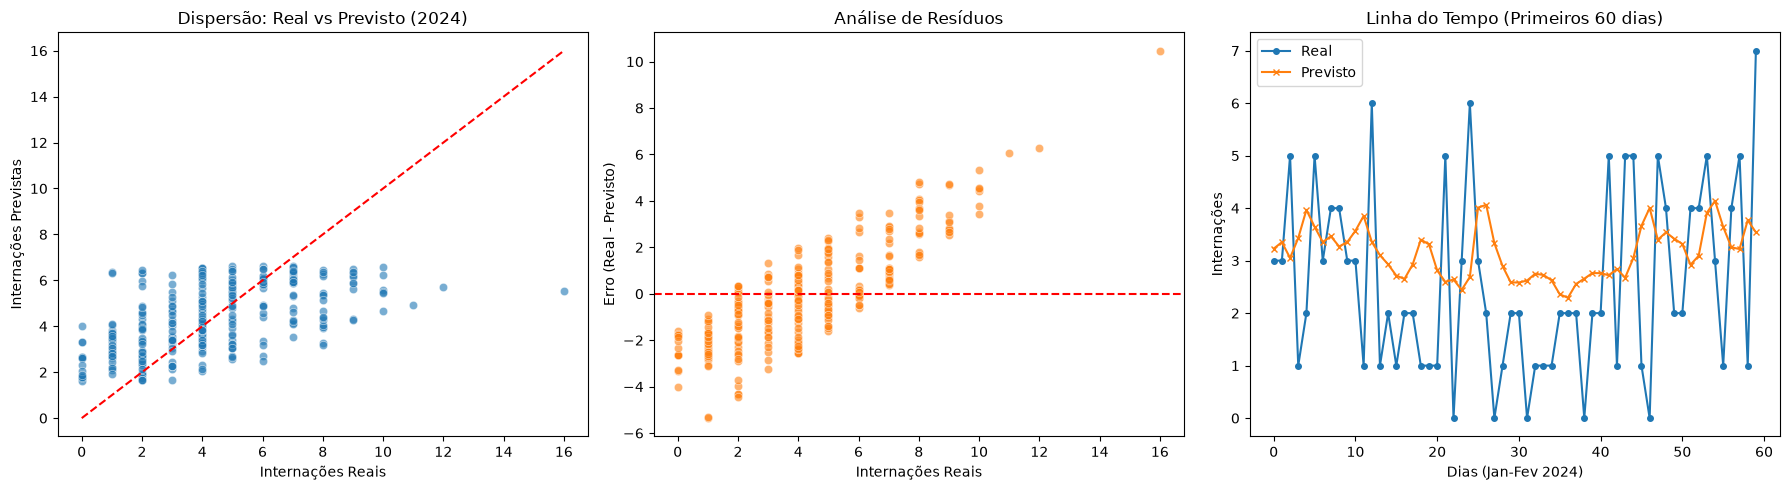

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extrair todas as previsões e valores reais do DataLoader de teste
model.eval()
previsoes_lstm = []
reais_lstm = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        preds = model(inputs)
        
        # Achata os tensores e move para a CPU
        previsoes_lstm.extend(preds.view(-1).cpu().numpy())
        reais_lstm.extend(labels.view(-1).cpu().numpy())

previsoes_lstm = np.array(previsoes_lstm)
reais_lstm = np.array(reais_lstm)
residuos = reais_lstm - previsoes_lstm

# 2. Configurar a figura com 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- PLOT 1: Scatter Plot (Real vs Previsto) ---
sns.scatterplot(x=reais_lstm, y=previsoes_lstm, alpha=0.6, ax=axes[0], color='#1f77b4')
# Linha perfeita (onde y_real == y_previsto)
max_val = max(max(reais_lstm), max(previsoes_lstm))
axes[0].plot([0, max_val], [0, max_val], color='red', linestyle='--')
axes[0].set_title('Dispersão: Real vs Previsto (2024)')
axes[0].set_xlabel('Internações Reais')
axes[0].set_ylabel('Internações Previstas')

# --- PLOT 2: Gráfico de Resíduos ---
sns.scatterplot(x=reais_lstm, y=residuos, alpha=0.6, ax=axes[1], color='#ff7f0e')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Análise de Resíduos')
axes[1].set_xlabel('Internações Reais')
axes[1].set_ylabel('Erro (Real - Previsto)')

# --- PLOT 3: Linha do Tempo (Amostra de 60 dias) ---
# Pegamos apenas os primeiros 60 dias para não poluir o gráfico
dias = 60
axes[2].plot(reais_lstm[:dias], label='Real', marker='o', markersize=4)
axes[2].plot(previsoes_lstm[:dias], label='Previsto', marker='x', markersize=4)
axes[2].set_title(f'Linha do Tempo (Primeiros {dias} dias)')
axes[2].set_xlabel('Dias (Jan-Fev 2024)')
axes[2].set_ylabel('Internações')
axes[2].legend()

plt.tight_layout()
plt.show()

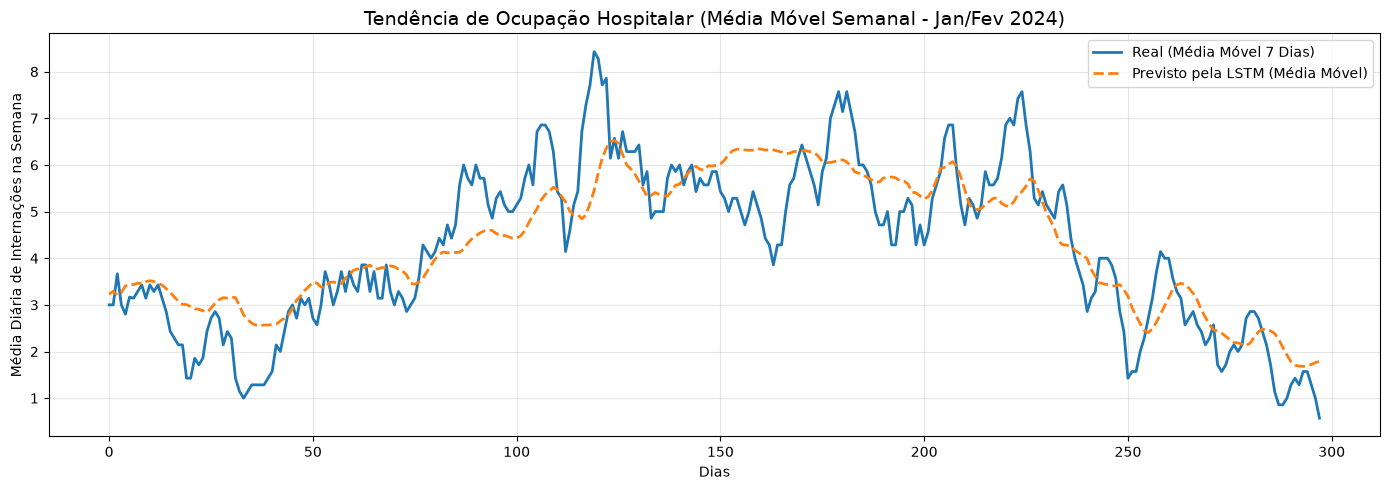

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Colocar os arrays em um DataFrame para facilitar o cálculo da janela
df_analise = pd.DataFrame({
    'Real': reais_lstm,
    'Previsto': previsoes_lstm
})

# 2. Calcular a Média Móvel de 7 dias
# Isso significa: "A ocupação média esperada para a próxima semana"
df_rolling = df_analise.rolling(window=7, min_periods=1).mean()

# 3. Plotar o resultado
plt.figure(figsize=(14, 5))
plt.plot(df_rolling['Real'], label='Real (Média Móvel 7 Dias)', linewidth=2, color='#1f77b4')
plt.plot(df_rolling['Previsto'], label='Previsto pela LSTM (Média Móvel)', linewidth=2, linestyle='--', color='#ff7f0e')

plt.title('Tendência de Ocupação Hospitalar (Média Móvel Semanal - Jan/Fev 2024)', fontsize=14)
plt.xlabel('Dias')
plt.ylabel('Média Diária de Internações na Semana')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

SHAP VALUES

Preparando SHAP para LSTM PyTorch...
Calculando contribuições marginais (Isso pode demorar um pouquinho)...


C:\Users\Usuario\AppData\Local\Temp\ipykernel_6932\1864741259.py:41: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
c:\Users\Usuario\Desktop\CIC\6\CDD\TRABALHO\GIT\Guri-Teimoso\.venv\Lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


<Figure size 1000x800 with 0 Axes>

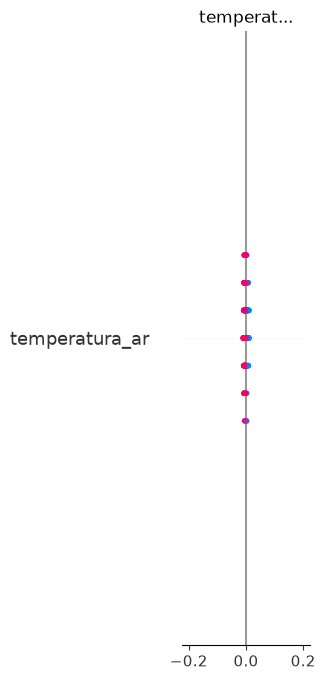

In [12]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt

print("Preparando SHAP para LSTM PyTorch...")

# 1. Preparar os tensores de Fundo (Background) e Teste
model.eval()

# O SHAP precisa de uma amostra de treino para entender qual é a "linha de base" (a média do modelo)
# Pegamos cerca de 100 amostras aleatórias do loader de treino
background_data = next(iter(DataLoader(train_dataset, batch_size=100, shuffle=True)))[0].to(device)

# Pegamos os dados de teste (2024) que queremos explicar
test_data = next(iter(DataLoader(test_dataset, batch_size=200, shuffle=False)))[0].to(device)

# 2. Instanciar o Explainer para PyTorch
# Usamos o GradientExplainer (frequentemente mais estável que o DeepExplainer para LSTMs)
explainer = shap.GradientExplainer(model, background_data)

# 3. Calcular os Valores SHAP
print("Calculando contribuições marginais (Isso pode demorar um pouquinho)...")
shap_values = explainer.shap_values(test_data)

# Tratamento do formato de saída (o SHAP muda dependendo da versão do PyTorch)
if isinstance(shap_values, list):
    shap_values = shap_values[0]

# O formato original é (amostras, 7_dias_da_janela, 29_features)
# Precisamos "esmagar" a dimensão do tempo (tirar a média do impacto dos 7 dias)
# para ver o impacto geral de cada feature, igual fizemos com o LightGBM.
shap_values_2d = np.mean(shap_values, axis=1) # Fica (amostras, 29_features)
test_data_2d = np.mean(test_data.cpu().numpy(), axis=1)

# Recuperar os nomes das colunas que entraram no pipeline
nomes_features = X_train_processed.columns.tolist()

# 4. Plotar o Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_2d, 
    test_data_2d, 
    feature_names=nomes_features,
    plot_type="dot",
    show=True
)